# 🛡️ PhishGuard
## Phishing URL Detection & Risk Analysis System

### Project Overview

PhishGuard is a machine-learning-based cybersecurity project
designed to analyze URLs and identify characteristics commonly
associated with potentially suspicious or phishing URLs.

The system extracts URL-based features, trains machine-learning
classification models, evaluates their performance, and provides
a risk assessment for newly entered URLs.

### Objectives

- Analyze URL characteristics
- Extract cybersecurity-related features
- Identify suspicious URL patterns
- Train machine-learning classification models
- Evaluate model performance
- Generate a risk score
- Explain why a URL was flagged

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse

print("PhishGuard environment initialized successfully.")

PhishGuard environment initialized successfully.


In [ ]:
data = {
    "url": [
        "https://example.com",
        "https://www.wikipedia.org",
        "https://www.microsoft.com",
        "https://www.apple.com",
        "https://github.com",
        "https://www.python.org",
        "http://login-example.com",
        "http://verify-account-example.com",
        "http://secure-login-example.com",
        "http://account-verification-example.com"
    ],

    "label": [
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        1
    ]
}

df = pd.DataFrame(data)

df

,url,label
0,https://example.com,0
1,https://www.wikipedia.org,0
2,https://www.microsoft.com,0
3,https://www.apple.com,0
4,https://github.com,0
5,https://www.python.org,0
6,http://login-example.com,1
7,http://verify-account-example.com,1
8,http://secure-login-example.com,1
9,http://account-verification-example.com,1


In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape:
(10, 2)

Column names:
Index(['url', 'label'], dtype='object')

First 5 rows:


,url,label
0,https://example.com,0
1,https://www.wikipedia.org,0
2,https://www.microsoft.com,0
3,https://www.apple.com,0
4,https://github.com,0


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
url      0
label    0
dtype: int64


In [ ]:
print("Class distribution:")
print(df["label"].value_counts())

Class distribution:
label
0    6
1    4
Name: count, dtype: int64


In [ ]:
def extract_features(url):

    features = {}

    parsed = urlparse(url)

    # Basic URL information
    features["url_length"] = len(url)

    # HTTPS
    features["https"] = 1 if parsed.scheme == "https" else 0

    # IP address detection
    ip_pattern = r"^(?:\d{1,3}\.){3}\d{1,3}$"
    features["has_ip"] = 1 if re.match(ip_pattern, parsed.netloc) else 0

    # Character counts
    features["dot_count"] = url.count(".")
    features["hyphen_count"] = url.count("-")
    features["at_count"] = url.count("@")
    features["digit_count"] = sum(c.isdigit() for c in url)

    # Special characters
    special_characters = ["@", "-", "_", "=", "&", "%", "?"]
    features["special_char_count"] = sum(
        url.count(char) for char in special_characters
    )

    # Suspicious keywords
    suspicious_words = [
        "login",
        "verify",
        "verification",
        "account",
        "secure",
        "update",
        "password",
        "confirm",
        "bank",
        "signin"
    ]

    url_lower = url.lower()

    features["suspicious_word_count"] = sum(
        word in url_lower for word in suspicious_words
    )

    # Subdomain count
    hostname = parsed.hostname

    if hostname:
        parts = hostname.split(".")
        features["subdomain_count"] = max(len(parts) - 2, 0)
    else:
        features["subdomain_count"] = 0

    # Common URL shorteners
    shorteners = [
        "bit.ly",
        "tinyurl.com",
        "t.co",
        "goo.gl",
        "ow.ly"
    ]

    features["shortener"] = int(
        any(shortener in url_lower for shortener in shorteners)
    )

    return features

In [ ]:
test_url = "http://secure-login-example.com/verify-account"

features = extract_features(test_url)

features

{'url_length': 46,
 'https': 0,
 'has_ip': 0,
 'dot_count': 1,
 'hyphen_count': 3,
 'at_count': 0,
 'digit_count': 0,
 'special_char_count': 3,
 'suspicious_word_count': 4,
 'subdomain_count': 0,
 'shortener': 0}

In [ ]:
legitimate_urls = [
    "https://www.google.com",
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://www.amazon.com",
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.python.org",
    "https://www.linkedin.com",
    "https://www.youtube.com",
    "https://www.reddit.com",
    "https://www.ibm.com",
    "https://www.adobe.com",
    "https://www.mozilla.org",
    "https://www.nasa.gov",
    "https://www.cnn.com",
    "https://www.bbc.com",
    "https://www.netflix.com",
    "https://www.spotify.com",
    "https://www.dropbox.com",
    "https://www.paypal.com"
]

print("Legitimate URLs:", len(legitimate_urls))

Legitimate URLs: 20


In [ ]:
phishing_urls = [
    "http://secure-login-example.com",
    "http://verify-account-example.com",
    "http://account-verification-example.com",
    "http://password-confirm-example.com",
    "http://secure-update-example.com",
    "http://login-verify-example.com",
    "http://bank-account-confirm-example.com",
    "http://signin-security-example.com",
    "http://account-update-example.com",
    "http://verify-user-example.com",
    "http://secure-login-example.com/verify",
    "http://account-example.com/login/verify",
    "http://user-verification-example.com/confirm",
    "http://password-update-example.com/account",
    "http://secure-account-example.com/login",
    "http://bank-security-example.com/verify",
    "http://signin-example.com/password",
    "http://account-confirm-example.com/update",
    "http://login-example.com/secure/verify",
    "http://verification-example.com/account"
]

print("Suspicious-pattern URLs:", len(phishing_urls))

Suspicious-pattern URLs: 20


In [ ]:
urls = legitimate_urls + phishing_urls

labels = (
    [0] * len(legitimate_urls) +
    [1] * len(phishing_urls)
)

dataset = pd.DataFrame({
    "url": urls,
    "label": labels
})

print("Total URLs:", len(dataset))
print("Legitimate:", sum(dataset["label"] == 0))
print("Suspicious:", sum(dataset["label"] == 1))

Total URLs: 40
Legitimate: 20
Suspicious: 20


In [ ]:
dataset = dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

dataset.head(10)

,url,label
0,https://www.paypal.com,0
1,https://www.netflix.com,0
2,https://www.bbc.com,0
3,http://bank-account-confirm-example.com,1
4,https://www.wikipedia.org,0
5,https://www.mozilla.org,0
6,http://account-confirm-example.com/update,1
7,http://signin-security-example.com,1
8,http://verification-example.com/account,1
9,https://www.python.org,0


In [ ]:
feature_data = dataset["url"].apply(extract_features)

features_df = pd.DataFrame(feature_data.tolist())

features_df.head()

,url_length,https,has_ip,dot_count,hyphen_count,at_count,digit_count,special_char_count,suspicious_word_count,subdomain_count,shortener
0,22,1,0,2,0,0,0,0,0,1,0
1,23,1,0,2,0,0,0,0,0,1,0
2,19,1,0,2,0,0,0,0,0,1,0
3,39,0,0,1,3,0,0,3,3,0,0
4,25,1,0,2,0,0,0,0,0,1,0


In [ ]:
final_dataset = pd.concat(
    [
        features_df,
        dataset["label"].reset_index(drop=True)
    ],
    axis=1
)

final_dataset.head()

,url_length,https,has_ip,dot_count,hyphen_count,at_count,digit_count,special_char_count,suspicious_word_count,subdomain_count,shortener,label
0,22,1,0,2,0,0,0,0,0,1,0,0
1,23,1,0,2,0,0,0,0,0,1,0,0
2,19,1,0,2,0,0,0,0,0,1,0,0
3,39,0,0,1,3,0,0,3,3,0,0,1
4,25,1,0,2,0,0,0,0,0,1,0,0


In [ ]:
print("Dataset shape:")
print(final_dataset.shape)

print("\nColumns:")
print(final_dataset.columns.tolist())

print("\nMissing values:")
print(final_dataset.isnull().sum())

Dataset shape:
(40, 12)

Columns:
['url_length', 'https', 'has_ip', 'dot_count', 'hyphen_count', 'at_count', 'digit_count', 'special_char_count', 'suspicious_word_count', 'subdomain_count', 'shortener', 'label']

Missing values:
url_length               0
https                    0
has_ip                   0
dot_count                0
hyphen_count             0
at_count                 0
digit_count              0
special_char_count       0
suspicious_word_count    0
subdomain_count          0
shortener                0
label                    0
dtype: int64


In [ ]:
final_dataset.describe()

,url_length,https,has_ip,dot_count,hyphen_count,at_count,digit_count,special_char_count,suspicious_word_count,subdomain_count,shortener,label
count,40.000000,40.00000,40.0,40.00000,40.000000,40.0,40.0,40.000000,40.000000,40.00000,40.000000,40.00000
mean,29.250000,0.50000,0.0,1.50000,0.925000,0.0,0.0,0.925000,1.125000,0.50000,0.050000,0.50000
std,7.963861,0.50637,0.0,0.50637,0.997111,0.0,0.0,0.997111,1.223436,0.50637,0.220721,0.50637
min,19.000000,0.00000,0.0,1.00000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.00000
25%,22.000000,0.00000,0.0,1.00000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.00000
50%,27.500000,0.50000,0.0,1.50000,0.500000,0.0,0.0,0.500000,0.500000,0.50000,0.000000,0.50000
75%,38.000000,1.00000,0.0,2.00000,2.000000,0.0,0.0,2.000000,2.000000,1.00000,0.000000,1.00000
max,44.000000,1.00000,0.0,2.00000,3.000000,0.0,0.0,3.000000,3.000000,1.00000,1.000000,1.00000


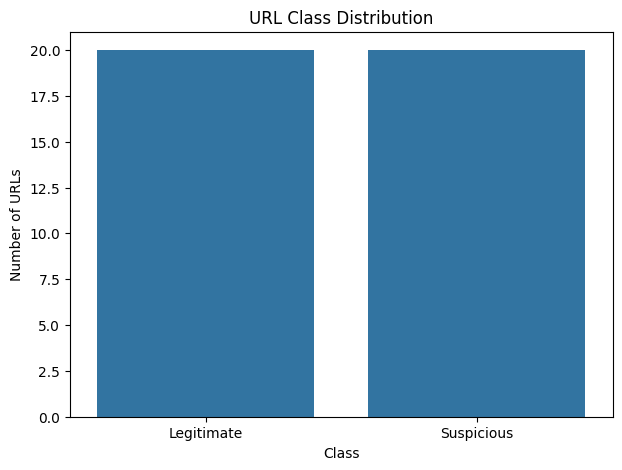

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="label",
    data=final_dataset
)

plt.title("URL Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")

plt.xticks(
    [0, 1],
    ["Legitimate", "Suspicious"]
)

plt.show()

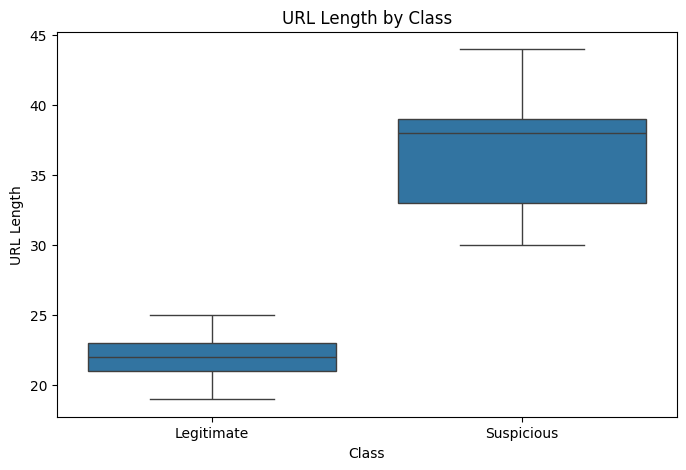

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="label",
    y="url_length",
    data=final_dataset
)

plt.title("URL Length by Class")
plt.xlabel("Class")
plt.ylabel("URL Length")

plt.xticks(
    [0, 1],
    ["Legitimate", "Suspicious"]
)

plt.show()

In [ ]:
import random

random.seed(42)

legitimate_domains = [
    "google.com",
    "microsoft.com",
    "apple.com",
    "amazon.com",
    "github.com",
    "wikipedia.org",
    "python.org",
    "linkedin.com",
    "youtube.com",
    "mozilla.org",
    "adobe.com",
    "ibm.com",
    "nasa.gov",
    "netflix.com",
    "spotify.com",
    "dropbox.com",
    "reddit.com",
    "stackoverflow.com",
    "cnn.com",
    "bbc.com"
]

legitimate_paths = [
    "",
    "/",
    "/home",
    "/about",
    "/contact",
    "/products",
    "/services",
    "/support",
    "/help",
    "/account",
    "/settings",
    "/news",
    "/blog"
]

suspicious_domains = [
    "secure-login-example.com",
    "account-verify-example.com",
    "login-security-example.com",
    "verify-account-example.com",
    "password-update-example.com",
    "bank-security-example.com",
    "account-confirm-example.com",
    "secure-verification-example.com",
    "user-login-example.com",
    "online-security-example.com"
]

suspicious_paths = [
    "/login",
    "/verify",
    "/verification",
    "/account",
    "/account/verify",
    "/login/confirm",
    "/password/update",
    "/secure/login",
    "/user/verify",
    "/account/confirmation"
]

print("URL templates created successfully.")

URL templates created successfully.


In [ ]:
def generate_legitimate_url():

    domain = random.choice(legitimate_domains)
    path = random.choice(legitimate_paths)

    protocol = random.choice([
        "https",
        "https",
        "https",
        "https",
        "http"
    ])

    return f"{protocol}://www.{domain}{path}"

In [ ]:
def generate_suspicious_url():

    domain = random.choice(suspicious_domains)
    path = random.choice(suspicious_paths)

    variations = [
        f"http://{domain}{path}",
        f"http://www.{domain}{path}",
        f"http://{domain}/secure{path}",
        f"http://{domain}/verify{path}",
        f"http://{domain}/account{path}"
    ]

    return random.choice(variations)

In [ ]:
legitimate_generated = [
    generate_legitimate_url()
    for _ in range(500)
]

suspicious_generated = [
    generate_suspicious_url()
    for _ in range(500)
]

all_urls = legitimate_generated + suspicious_generated

all_labels = (
    [0] * 500 +
    [1] * 500
)

large_dataset = pd.DataFrame({
    "url": all_urls,
    "label": all_labels
})

large_dataset = large_dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Total rows:", len(large_dataset))
print("Legitimate:", sum(large_dataset["label"] == 0))
print("Suspicious:", sum(large_dataset["label"] == 1))

Total rows: 1000
Legitimate: 500
Suspicious: 500


In [ ]:
large_dataset.head(20)

,url,label
0,http://user-login-example.com/account/verify,1
1,http://account-confirm-example.com/account/login,1
2,http://account-confirm-example.com/verify/user...,1
3,http://account-verify-example.com/secure/passw...,1
4,https://www.mozilla.org/blog,0
5,http://secure-verification-example.com/secure/...,1
6,http://www.online-security-example.com/login/c...,1
7,http://www.account-verify-example.com/login,1
8,http://secure-login-example.com/account/passwo...,1
9,https://www.stackoverflow.com/news,0


In [ ]:
duplicate_count = large_dataset["url"].duplicated().sum()

print("Duplicate URLs:", duplicate_count)

Duplicate URLs: 400


In [ ]:
large_dataset = large_dataset.drop_duplicates(
    subset="url"
).reset_index(drop=True)

print("Dataset size after removing duplicates:",
      len(large_dataset))

Dataset size after removing duplicates: 600


In [ ]:
large_features = large_dataset["url"].apply(
    extract_features
)

large_features_df = pd.DataFrame(
    large_features.tolist()
)

large_features_df.head()

In [ ]:
print(
    ml_dataset["label"].value_counts()
)

label
1    318
0    282
Name: count, dtype: int64


In [ ]:
ml_dataset.to_csv(
    "phishguard_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [ ]:
print("Number of rows:", len(ml_dataset))
print("Number of features:", len(ml_dataset.columns) - 1)
print("Total columns:", len(ml_dataset.columns))

Number of rows: 600
Number of features: 11
Total columns: 12


In [ ]:
print("Features used by PhishGuard:\n")

for i, column in enumerate(ml_dataset.columns, start=1):
    print(i, "-", column)

Features used by PhishGuard:

1 - url_length
2 - https
3 - has_ip
4 - dot_count
5 - hyphen_count
6 - at_count
7 - digit_count
8 - special_char_count
9 - suspicious_word_count
10 - subdomain_count
11 - shortener
12 - label


In [ ]:
ml_dataset.describe().round(2)

,url_length,https,has_ip,dot_count,hyphen_count,at_count,digit_count,special_char_count,suspicious_word_count,subdomain_count,shortener,label
count,600.00,600.00,600.0,600.00,600.00,600.0,600.0,600.00,600.00,600.00,600.00,600.00
mean,40.42,0.34,0.0,1.58,1.06,0.0,0.0,1.06,1.68,0.58,0.04,0.53
std,12.64,0.48,0.0,0.49,1.00,0.0,0.0,1.00,1.68,0.49,0.20,0.50
min,18.00,0.00,0.0,1.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00
25%,28.00,0.00,0.0,1.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00
50%,42.00,0.00,0.0,2.00,2.00,0.0,0.0,2.00,2.00,1.00,0.00,1.00
75%,52.00,1.00,0.0,2.00,2.00,0.0,0.0,2.00,3.00,1.00,0.00,1.00
max,67.00,1.00,0.0,2.00,2.00,0.0,0.0,2.00,5.00,1.00,1.00,1.00


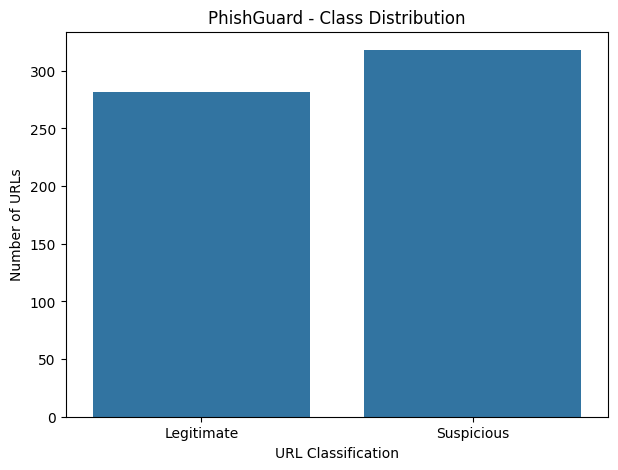

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="label",
    data=ml_dataset
)

plt.title("PhishGuard - Class Distribution")
plt.xlabel("URL Classification")
plt.ylabel("Number of URLs")

plt.xticks(
    [0, 1],
    ["Legitimate", "Suspicious"]
)

plt.show()

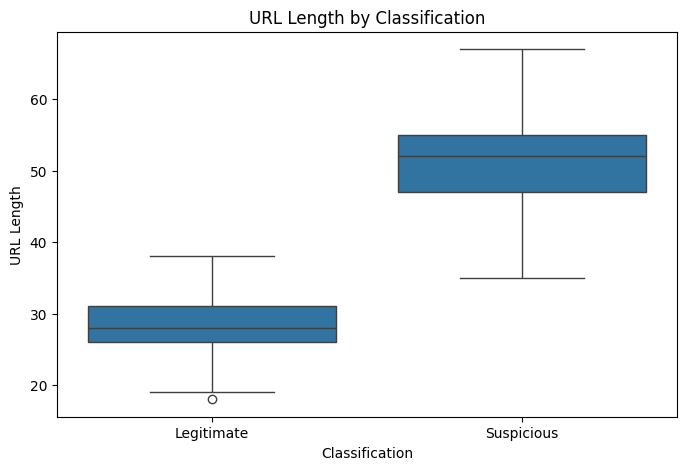

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="label",
    y="url_length",
    data=ml_dataset
)

plt.title("URL Length by Classification")
plt.xlabel("Classification")
plt.ylabel("URL Length")

plt.xticks(
    [0, 1],
    ["Legitimate", "Suspicious"]
)

plt.show()

In [ ]:
https_analysis = pd.crosstab(
    ml_dataset["https"],
    ml_dataset["label"]
)

https_analysis

label,0,1
https,,
0,76,318
1,206,0


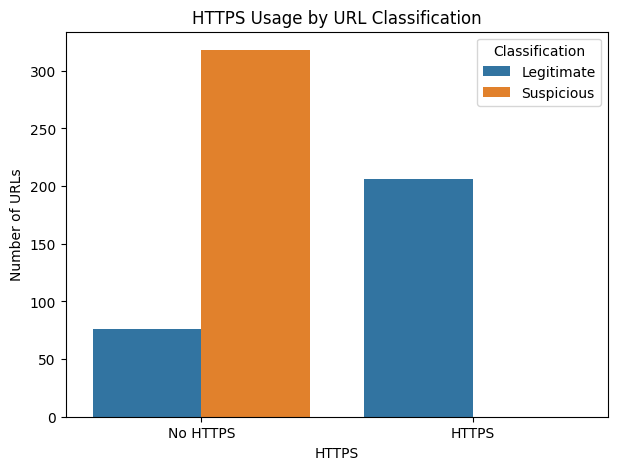

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="https",
    hue="label",
    data=ml_dataset
)

plt.title("HTTPS Usage by URL Classification")
plt.xlabel("HTTPS")
plt.ylabel("Number of URLs")

plt.xticks(
    [0, 1],
    ["No HTTPS", "HTTPS"]
)

plt.legend(
    title="Classification",
    labels=["Legitimate", "Suspicious"]
)

plt.show()

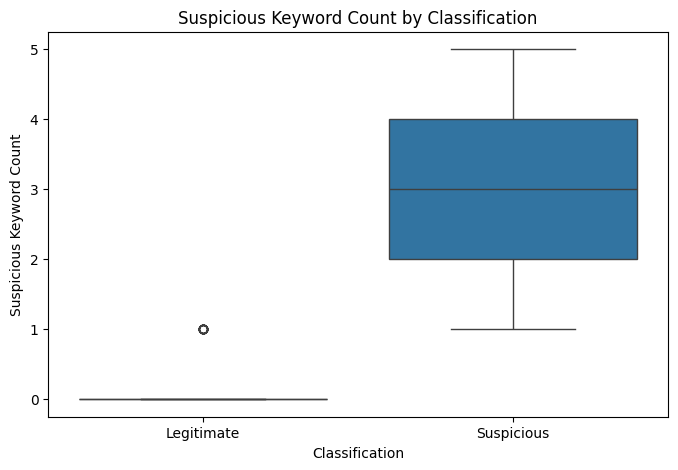

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="label",
    y="suspicious_word_count",
    data=ml_dataset
)

plt.title("Suspicious Keyword Count by Classification")
plt.xlabel("Classification")
plt.ylabel("Suspicious Keyword Count")

plt.xticks(
    [0, 1],
    ["Legitimate", "Suspicious"]
)

plt.show()

In [ ]:
ip_analysis = pd.crosstab(
    ml_dataset["has_ip"],
    ml_dataset["label"]
)

ip_analysis

label,0,1
has_ip,,
0,282,318


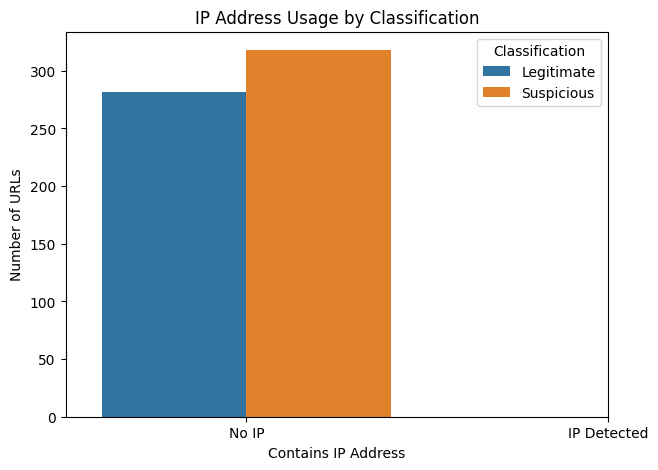

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="has_ip",
    hue="label",
    data=ml_dataset
)

plt.title("IP Address Usage by Classification")
plt.xlabel("Contains IP Address")
plt.ylabel("Number of URLs")

plt.xticks(
    [0, 1],
    ["No IP", "IP Detected"]
)

plt.legend(
    title="Classification",
    labels=["Legitimate", "Suspicious"]
)

plt.show()

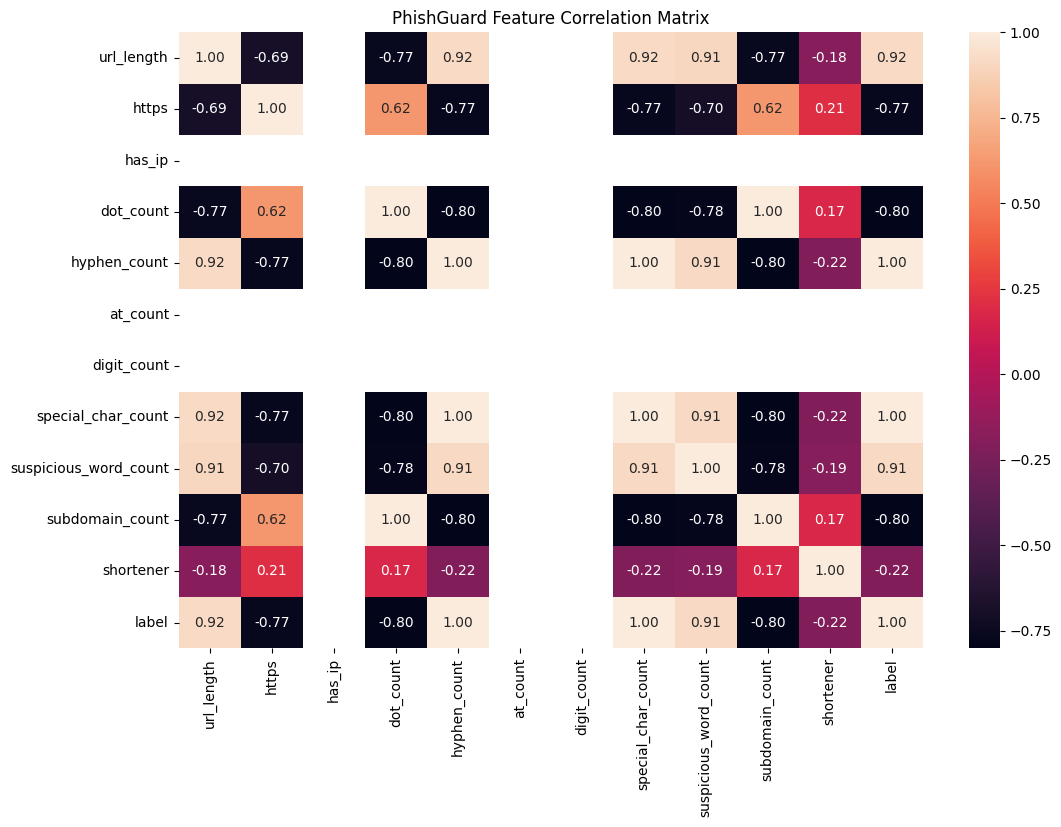

In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = ml_dataset.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("PhishGuard Feature Correlation Matrix")

plt.show()

In [ ]:
label_correlations = (
    ml_dataset.corr()["label"]
    .drop("label")
    .sort_values(
        ascending=False
    )
)

label_correlations

,label
hyphen_count,1.000000
special_char_count,1.000000
url_length,0.920445
suspicious_word_count,0.908797
shortener,-0.216762
https,-0.767847
subdomain_count,-0.801349
dot_count,-0.801349
has_ip,NaN
at_count,NaN


In [ ]:
X = ml_dataset.drop("label", axis=1)
y = ml_dataset["label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (600, 11)
Target shape: (600,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 480
Testing samples: 120


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

print(logistic_predictions[:20])

[0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [ ]:
tree_predictions = decision_tree.predict(
    X_test
)

print(tree_predictions[:20])

[0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1]


In [ ]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions
)

tree_recall = recall_score(
    y_test,
    tree_predictions
)

tree_f1 = f1_score(
    y_test,
    tree_predictions
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Decision Tree Results
---------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
forest_predictions = random_forest.predict(
    X_test
)

print(forest_predictions[:20])

[0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1]


In [ ]:
forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)

forest_precision = precision_score(
    y_test,
    forest_predictions
)

forest_recall = recall_score(
    y_test,
    forest_predictions
)

forest_f1 = f1_score(
    y_test,
    forest_predictions
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1 Score :", round(forest_f1, 4))

Random Forest Results
---------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


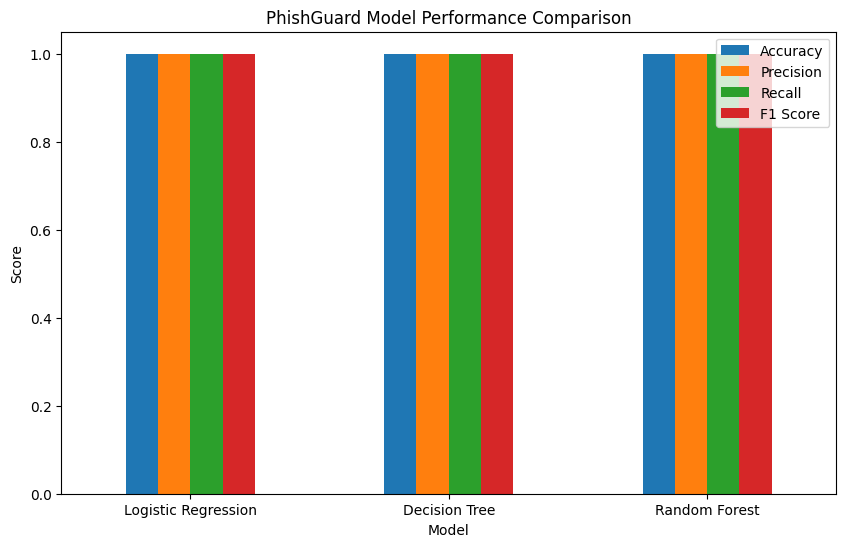

In [ ]:
model_results_plot = model_results.set_index("Model")

model_results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("PhishGuard Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    forest_predictions
)

print(cm)

[[56  0]
 [ 0 64]]


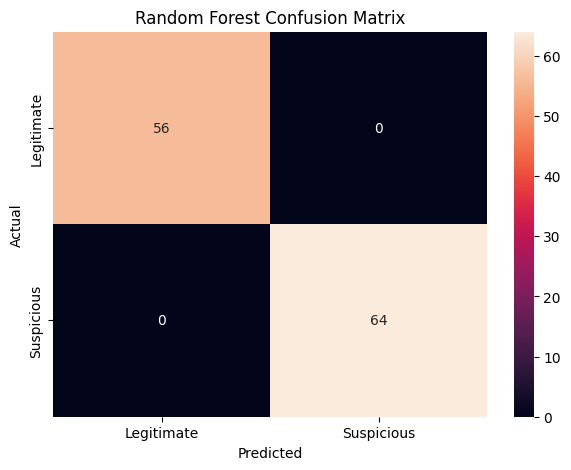

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Suspicious"],
    yticklabels=["Legitimate", "Suspicious"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,hyphen_count,0.292870
7,special_char_count,0.260274
0,url_length,0.202880
8,suspicious_word_count,0.136213
9,subdomain_count,0.047164
1,https,0.031192
3,dot_count,0.028193
10,shortener,0.001213
2,has_ip,0.000000
6,digit_count,0.000000


In [ ]:
feature_importance.round(4)

,Feature,Importance
4,hyphen_count,0.2929
7,special_char_count,0.2603
0,url_length,0.2029
8,suspicious_word_count,0.1362
9,subdomain_count,0.0472
1,https,0.0312
3,dot_count,0.0282
10,shortener,0.0012
2,has_ip,0.0000
6,digit_count,0.0000


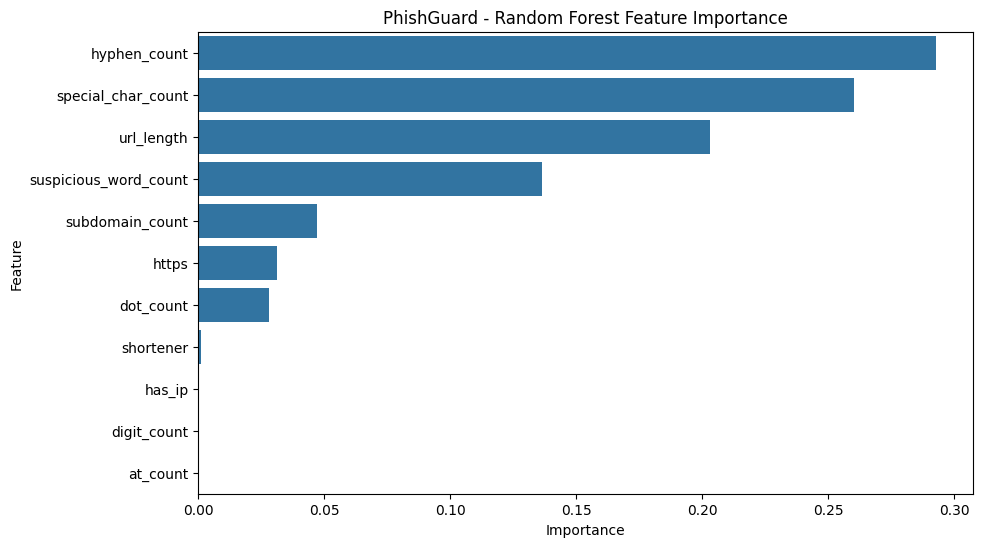

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("PhishGuard - Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
def predict_url(url):

    # Extract URL features
    features = extract_features(url)

    # Convert to DataFrame
    feature_df = pd.DataFrame([features])

    # Make prediction
    prediction = random_forest.predict(feature_df)[0]

    # Get probability
    probability = random_forest.predict_proba(
        feature_df
    )[0]

    suspicious_probability = probability[1]

    if prediction == 1:
        classification = "Suspicious"
    else:
        classification = "Legitimate"

    return classification, suspicious_probability

In [ ]:
test_url = "https://www.github.com"

result, probability = predict_url(test_url)

print("URL:", test_url)
print("Classification:", result)
print("Suspicious Probability:", round(probability * 100, 2), "%")

URL: https://www.github.com
Classification: Legitimate
Suspicious Probability: 0.0 %


In [ ]:
test_url = "http://secure-login-example.com/verify-account"

result, probability = predict_url(test_url)

print("URL:", test_url)
print("Classification:", result)
print("Suspicious Probability:", round(probability * 100, 2), "%")

URL: http://secure-login-example.com/verify-account
Classification: Suspicious
Suspicious Probability: 100.0 %


In [ ]:
def calculate_risk_score(probability):

    risk_score = round(probability * 100)

    if risk_score < 30:
        risk_level = "Low Risk"
    elif risk_score < 70:
        risk_level = "Medium Risk"
    else:
        risk_level = "High Risk"

    return risk_score, risk_level

In [ ]:
def analyze_url(url):

    # Extract features
    features = extract_features(url)

    # Convert to DataFrame
    feature_df = pd.DataFrame([features])

    # Prediction
    prediction = random_forest.predict(
        feature_df
    )[0]

    # Probability
    probabilities = random_forest.predict_proba(
        feature_df
    )[0]

    suspicious_probability = probabilities[1]

    # Risk score
    risk_score, risk_level = calculate_risk_score(
        suspicious_probability
    )

    # Classification
    if prediction == 1:
        classification = "Suspicious"
    else:
        classification = "Legitimate"

    return {
        "URL": url,
        "Classification": classification,
        "Risk Score": risk_score,
        "Risk Level": risk_level,
        "Suspicious Probability": round(
            suspicious_probability * 100, 2
        ),
        "Features": features
    }

In [69]:
result = analyze_url(
    "http://secure-login-example.com/verify-account"
)

print("URL:", result["URL"])
print("Classification:", result["Classification"])
print("Risk Score:", result["Risk Score"], "/ 100")
print("Risk Level:", result["Risk Level"])
print(
    "Suspicious Probability:",
    result["Suspicious Probability"],
    "%"
)

URL: http://secure-login-example.com/verify-account
Classification: Suspicious
Risk Score: 100 / 100
Risk Level: High Risk
Suspicious Probability: 100.0 %


In [71]:
def explain_url(url):

    features = extract_features(url)

    reasons = []

    if features["https"] == 0:
        reasons.append(
            "URL does not use HTTPS."
        )

    if features["has_ip"] == 1:
        reasons.append(
            "URL uses an IP address instead of a standard domain."
        )

    if features["url_length"] > 75:
        reasons.append(
            "URL is unusually long."
        )

    if features["hyphen_count"] >= 3:
        reasons.append(
            "URL contains multiple hyphens."
        )

    if features["at_count"] > 0:
        reasons.append(
            "URL contains an @ symbol."
        )

    if features["suspicious_word_count"] > 0:
        reasons.append(
            "URL contains potentially suspicious keywords."
        )

    if features["subdomain_count"] >= 3:
        reasons.append(
            "URL contains multiple subdomain levels."
        )

    if features["shortener"] == 1:
        reasons.append(
            "URL appears to use a common URL-shortening service."
        )

    if not reasons:
        reasons.append(
            "No major rule-based indicators were detected."
        )

    return reasons

In [72]:
url_to_check = "http://secure-login-example.com/verify-account"

analysis = analyze_url(url_to_check)
reasons = explain_url(url_to_check)

print("===================================")
print("          PHISHGUARD")
print("===================================")

print("URL:", analysis["URL"])
print("Classification:", analysis["Classification"])
print("Risk Score:", analysis["Risk Score"], "/ 100")
print("Risk Level:", analysis["Risk Level"])
print(
    "Suspicious Probability:",
    analysis["Suspicious Probability"],
    "%"
)

print("\nWhy was it flagged?")

for reason in reasons:
    print("•", reason)

          PHISHGUARD
URL: http://secure-login-example.com/verify-account
Classification: Suspicious
Risk Score: 100 / 100
Risk Level: High Risk
Suspicious Probability: 100.0 %

Why was it flagged?
• URL does not use HTTPS.
• URL contains multiple hyphens.
• URL contains potentially suspicious keywords.


In [73]:
!pip -q install gradio

In [74]:
import gradio as gr

In [75]:
def gradio_analyze(url):

    if not url or not url.strip():
        return (
            "No URL",
            0,
            "No Result",
            "Please enter a URL to analyze."
        )

    try:
        url = url.strip()

        # Run our PhishGuard analysis
        analysis = analyze_url(url)

        # Generate explanations
        reasons = explain_url(url)

        if reasons:
            reason_text = "\n".join([f"• {reason}" for reason in reasons])
        else:
            reason_text = "• No major rule-based warning indicators detected."

        explanation = (
            f"Suspicious Probability: "
            f"{analysis['Suspicious Probability']}%\n\n"
            f"Indicators:\n{reason_text}"
        )

        return (
            analysis["Classification"],
            analysis["Risk Score"],
            analysis["Risk Level"],
            explanation
        )

    except Exception as e:

        return (
            "Error",
            0,
            "Error",
            f"Something went wrong: {str(e)}"
        )

In [77]:
with gr.Blocks(title="PhishGuard") as demo:

    gr.Markdown(
        """
        # 🛡️ PhishGuard
        ### Phishing URL Detection & Risk Analysis System

        Enter a URL below to analyze its structural characteristics
        and estimate its phishing risk.
        """
    )

    gr.Markdown(
        """
        **Educational prototype:** Results are generated using a
        machine-learning model trained on a synthetic dataset.
        """
    )

    url_input = gr.Textbox(
        label="Enter URL",
        placeholder="https://example.com",
        lines=1
    )

    analyze_button = gr.Button(
        "🔍 Analyze URL"
    )

    classification = gr.Textbox(
        label="Classification"
    )

    risk_score = gr.Number(
        label="Risk Score (%)"
    )

    risk_level = gr.Textbox(
        label="Risk Level"
    )

    explanation = gr.Textbox(
        label="Analysis & Indicators",
        lines=10
    )

    analyze_button.click(
        fn=gradio_analyze,
        inputs=url_input,
        outputs=[
            classification,
            risk_score,
            risk_level,
            explanation
        ]
    )

In [78]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11b6416bbf72eccf80.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [80]:
def get_model_summary():

    best_model = model_results.loc[
        model_results["F1 Score"].idxmax()
    ]

    return (
        f"Best F1 Score: {best_model['F1 Score']:.2%}\n"
        f"Best Accuracy: {best_model['Accuracy']:.2%}\n"
        f"Best Model: {best_model['Model']}"
    )

In [81]:
feature_importance_display = feature_importance.copy()

feature_importance_display["Importance"] = (
    feature_importance_display["Importance"].round(4)
)

feature_importance_display

,Feature,Importance
4,hyphen_count,0.2929
7,special_char_count,0.2603
0,url_length,0.2029
8,suspicious_word_count,0.1362
9,subdomain_count,0.0472
1,https,0.0312
3,dot_count,0.0282
10,shortener,0.0012
2,has_ip,0.0000
6,digit_count,0.0000


In [82]:
with gr.Blocks(
    title="PhishGuard — Cybersecurity URL Analyzer"
) as professional_demo:

    gr.Markdown(
        """
        # 🛡️ PhishGuard
        ## Cybersecurity URL Detection & Risk Analysis

        **Machine-learning powered phishing URL analysis prototype**
        """
    )

    gr.Markdown(
        """
        PhishGuard extracts structural characteristics from a URL,
        applies a trained machine-learning model, and provides a
        model-based risk estimate together with rule-based indicators.
        """
    )

    with gr.Tab("🔍 URL Analyzer"):

        gr.Markdown(
            "### Analyze a suspicious or legitimate-style URL"
        )

        url_input_2 = gr.Textbox(
            label="URL",
            placeholder="https://example.com"
        )

        analyze_button_2 = gr.Button(
            "🔎 Analyze URL"
        )

        with gr.Row():

            classification_2 = gr.Textbox(
                label="Classification"
            )

            risk_score_2 = gr.Number(
                label="Risk Score (%)"
            )

            risk_level_2 = gr.Textbox(
                label="Risk Level"
            )

        explanation_2 = gr.Textbox(
            label="Security Analysis",
            lines=12
        )

        analyze_button_2.click(
            fn=gradio_analyze,
            inputs=url_input_2,
            outputs=[
                classification_2,
                risk_score_2,
                risk_level_2,
                explanation_2
            ]
        )

    with gr.Tab("📊 Model Performance"):

        gr.Markdown(
            """
            ### Machine Learning Model Comparison

            The following models were trained and evaluated using
            the synthetic PhishGuard dataset.
            """
        )

        gr.Dataframe(
            value=model_results,
            label="Model Performance"
        )

        gr.Markdown(
            """
            **Evaluation metrics**

            - Accuracy
            - Precision
            - Recall
            - F1 Score
            """
        )

    with gr.Tab("🧠 Feature Importance"):

        gr.Markdown(
            """
            ### Random Forest Feature Importance

            These features contributed to the Random Forest's
            predictions within the training dataset.
            """
        )

        gr.Dataframe(
            value=feature_importance_display,
            label="Feature Importance"
        )

        gr.Markdown(
            """
            **Important:** Feature importance indicates how useful
            features were to this trained model. It does not prove
            that a feature independently causes phishing behavior.
            """
        )

    gr.Markdown(
        """
        ---
        ### ⚠️ Project Disclaimer

        PhishGuard is an educational cybersecurity prototype.
        The machine-learning model was trained using a synthetic
        dataset and should not be treated as a production phishing
        detection service or a definitive security verdict.
        """
    )

In [83]:
professional_demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://61d8fb7aa6dd745164.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [84]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
gradio
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [85]:
import os

print("PhishGuard Project Files:")
print("-" * 35)

for file in os.listdir():
    if (
        file.endswith(".ipynb")
        or file.endswith(".csv")
        or file == "requirements.txt"
    ):
        print("✓", file)

PhishGuard Project Files:
-----------------------------------
✓ requirements.txt
✓ phishguard_dataset.csv


In [86]:
from google.colab import files

files.download("phishguard_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>